In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

PROCESSED_PATH = "C:/Users/kalam/F1 Project Outcome Prediction/data/processed/"
df = pd.read_csv(PROCESSED_PATH + "f1_features.csv")

In [2]:
features = [
    "year", "round", "grid", "quali_position",
    "driver_experience", "prev_wins", "prev_podiums",
    "prev_avg_finish", "recent_avg_finish_5",
    "constructor_prev_avg_points", "pit_stop_count",
    "mean_pit_stop_duration_ms", "avg_lap_time_ms"
]

X = df[features]
y = df["is_podium"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [4]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
2,grid,0.175971
8,recent_avg_finish_5,0.120486
9,constructor_prev_avg_points,0.119050
7,prev_avg_finish,0.104034
6,prev_podiums,0.091690
4,driver_experience,0.085005
5,prev_wins,0.071657
0,year,0.063622
1,round,0.063004
12,avg_lap_time_ms,0.039583


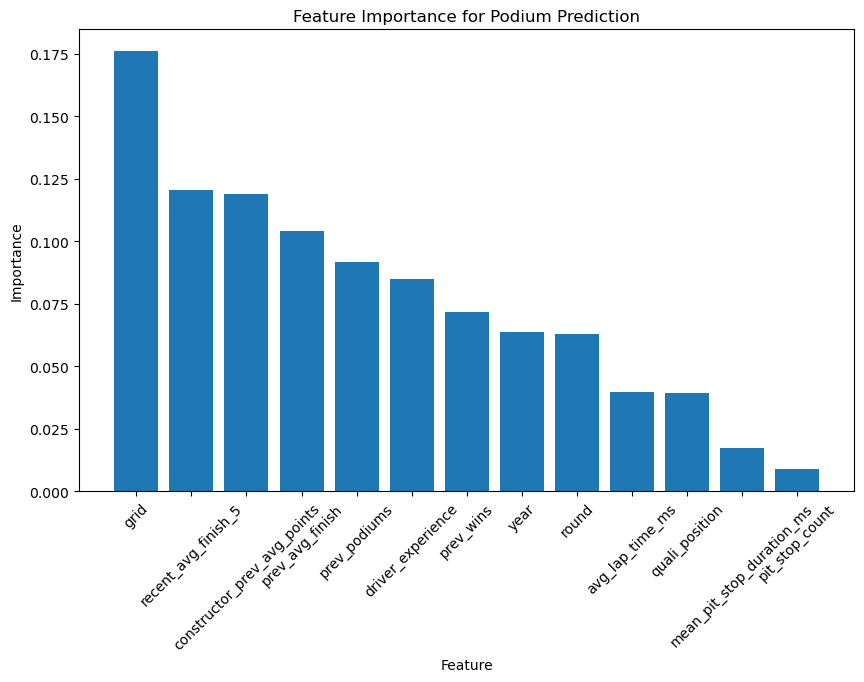

In [5]:
plt.figure(figsize=(10, 6))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Feature Importance for Podium Prediction")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()